# Gradient Descent 

## Analogy
Imagine you are at the top of a mountain in a thick fog. You want to get to the **very bottom (the lowest point of the valley)*, but you can't see the path.
- **What do you do?** - You feel the slope of the ground under your feet.

> If the **ground slopes down to the left, you take a small step to the left.** You keep doing this until the ground is flat.

## The Cost Function: J(m)
To reach the bottom, we need to know how "high" we are. In Machine Learning, "height" is Error.  We use the **Mean Squared Error (MSE):**

> MSE: J(m, b) = $\frac{1}{n}$ $\sum_{i=1}^{n}$ ($y_{actual}$ - $y_{predicted}$)<sup>2</sup>

To know which way is **"down"**, we take the **derivative** of the Cost Function with respect to our weights (m). The derivative tells us the slope.

> **For a weight $m_{j}$,** the gradient is: $\frac{∂J}{∂m_{j}}$     = $\frac{2}{n}$ $\sum_{i=1}^{n}$ ($y_{predicted}$ - $y_{actual}$) . $x_{j}$

> Once we know the slope, we update our weights: $m_{new} = m_{old} - (Learning Rate * Gradient)$ 

**Learning Rate (α):** The size of the step we take.
- **Too big?** - You might jump over the valley.
- **Too small?** - It will take forever to get to the bottom.

## Gradient Descent from Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Optimization loop
        for i in range(self.epochs):
            # Prediction: y = WX + b
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate Gradients (the slopes)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) # dw is the derivative w.r.t weights
            db = (1 / n_samples) * np.sum(y_predicted - y) # db is the derivative w.r.t bias
            
            # Update weights and bias (take the step)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Record the cost 
            cost = np.mean((y - y_predicted)**2)
            self.cost_history.append(cost)
            
            if i % 100 == 0:
                print(f"Epoch {i}: Cost {cost:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Epoch 0: Cost 29572500000.0000
Epoch 100: Cost 285878808.5407
Epoch 200: Cost 285878787.8788
Epoch 300: Cost 285878787.8788
Epoch 400: Cost 285878787.8788
Epoch 500: Cost 285878787.8788
Epoch 600: Cost 285878787.8788
Epoch 700: Cost 285878787.8788
Epoch 800: Cost 285878787.8788
Epoch 900: Cost 285878787.8788


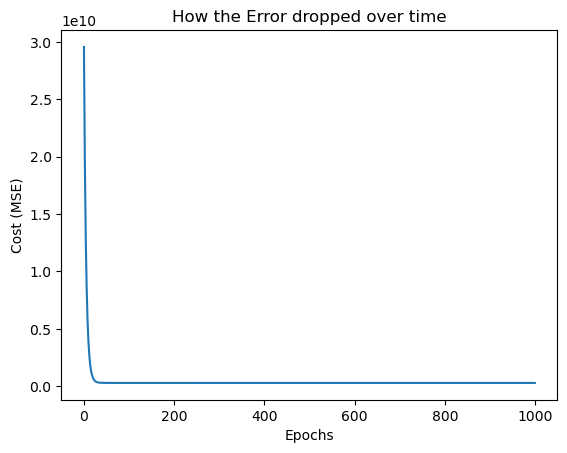

In [3]:
# 1. Create Dummy Dataset
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([45000, 50000, 60000, 80000, 110000, 150000, 190000, 230000, 260000, 300000])

# 2. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train Model
model = LinearRegressionGD(learning_rate=0.1, epochs=1000)
model.fit(X_scaled, y)

# 4. Plot the Cost History
plt.plot(range(len(model.cost_history)), model.cost_history)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("How the Error dropped over time")
plt.show()

## Linear Regression with/without Gradient Descent

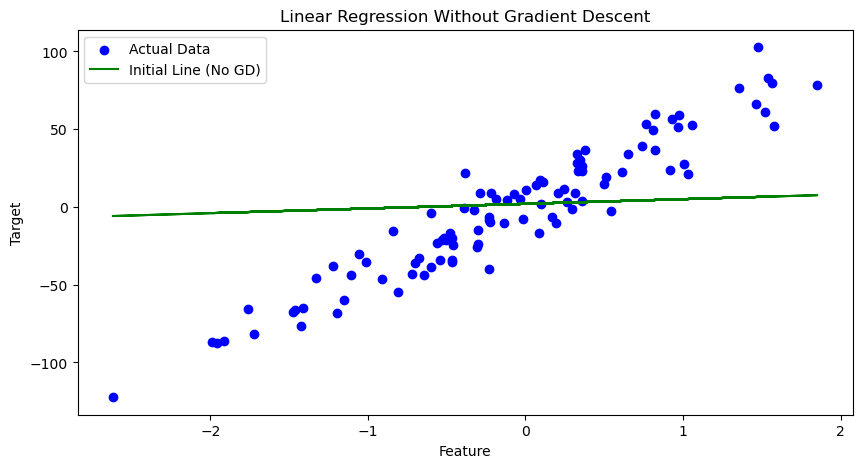

In [4]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1)
m = X.shape[0]

X_b = np.c_[np.ones((m, 1)), X]
theta = np.array([[2.0], [3.0]])

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="green", label="Initial Line (No GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Without Gradient Descent")
plt.legend()
plt.show()

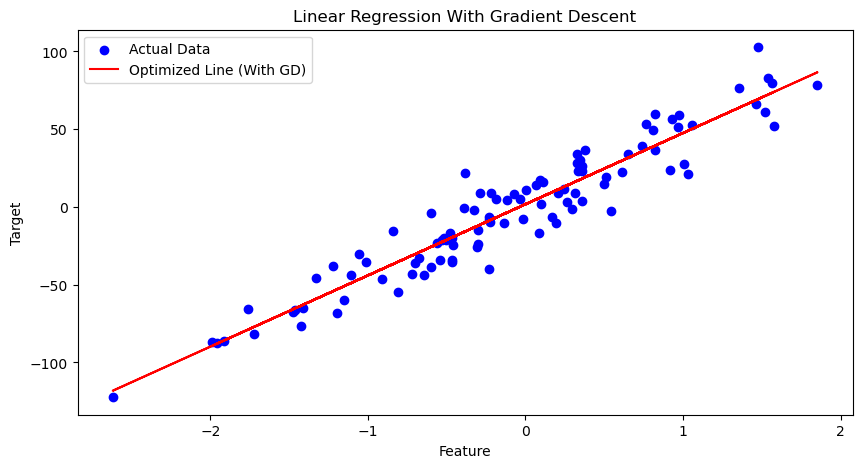

In [5]:
learning_rate = 0.1
n_iterations = 100

for _ in range(n_iterations):
    y_pred = X_b.dot(theta)
    gradients = (2 / m) * X_b.T.dot(y_pred - y)
    theta -= learning_rate * gradients

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="red", label="Optimized Line (With GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression With Gradient Descent")
plt.legend()
plt.show()